# Description:

This notebook provides a collection of analysis functions for multicomponent glass structures based on LAMMPS dump files.
It supports structural characterization using atomic-level information based on the features described below.

## Available Analyses:

- Coordination Numbers: Computes how many neighbors each atom has within a cutoff.
- Bridging and Non-Bridging Oxygens: Determines network connectivity through oxygen coordination.
- Qn Distribution: Counts the number of bridging oxygens attached to each former (e.g., Si), yielding Qn statistics.
- Network Connectivity: Computes average Qⁿ value across the system.
- Bond Angle Distribution: Calculates the angles between triplets of atoms to assess structural order.
- Radial distribution function: calculate the pairwise radial distribution functions g_ij(r) for all pairs of types i-j, normalized to ideal gas. it also calculate the cumulative coordination number CN_ij(r) obtained by integrating the RDF up to each r. 
- Guttmann Rings: get the rings size distribution following Guttmann algorithm.


## Input Requirements:
Currently, all functions assume LAMMPS dump file format (optionally gzipped). The simulation cell needs to be cubic or orthorhombic.
The required fields in the dump file are: atom ID, type, coordinates (wrapped or unwrapped), and box dimensions.

## Main Functions:

- `read_lammps_dump()`: Read atom data and box size.
- `remove_atom_type()`: Remove unwanted atom types.
- `compute_cell_list()`, `get_neighbors()`: neighbor search using a cell list.
- `compute_coordination()`: Coordination histogram for a given atom type.
- `compute_Qn()`: Compute Qⁿ and partial Qⁿ distributions.
- `compute_network_connectivity()`: Calculate the average Qⁿ.
- `compute_angles()`: Compute bond angle distributions (partial implementation).
- `compute_rdf()`: Compute radial distributions function and cumulative coordination number of all pairs in the sample.
- `write_distribution_to_file()`: Output histogram data to file.
- `compute_guttmann_rings()`: get guttmann rings statistics.



In [2]:
import matplotlib.pyplot as plt
import numpy as np
from ase.io import read

from pyiron_glass.io_utils import (
    write_distribution_to_file,
)
from pyiron_glass.analysis.qn_network_connectivity import (
    compute_qn,
    compute_network_connectivity,
)
from pyiron_glass.analysis.radial_distribution_functions import (
    compute_coordination,
    compute_rdf,
)
from pyiron_glass.analysis.bond_angle_distribution import compute_angles
from pyiron_glass.analysis.rings import (
    generate_bond_length_dict,
    compute_guttmann_rings,
)

# Coordination numbers and $Q^n$:

The cell below serves as a show case for calculating:

- Coordination Numbers: Computes how many neighbors each atom has within a cutoff.
- Bridging and Non-Bridging Oxygens: Determines network connectivity through oxygen coordination.
- Qn Distribution: Counts the number of bridging oxygens attached to each former (e.g., Si), yielding Qn statistics.
- Network Connectivity: Computes average Qⁿ value across the system.


In [3]:
# --- I/O ---
filename = "data/SiONa_5.dump.extxyz"
atoms = read("data/SiONa_5.extxyz")


# --- Grouping and cutoffs now in atomic-number space ---
type_map = {8: "O", 14: "Si", 11: "Na"}  # Z -> symbol
network_formers = {"Si"}
modifiers = {"Na"}
cutoff_map = {"O": 2.0, "Si": 2.0, "Na": 3.0}

O_type = [8]
former_types = [14]
modifier_types = [11]

# --- Coordination/Qn using your existing functions ---
O_coord, _ = compute_coordination(atoms, O_type, cutoff_map["O"], former_types)

former_coords = {
    type_map[t]: compute_coordination(atoms, [t], cutoff_map[type_map[t]], O_type)[0]
    for t in former_types
}

modifier_coords = {
    type_map[t]: compute_coordination(atoms, [t], cutoff_map[type_map[t]], O_type)[0]
    for t in modifier_types
}

Qn_dist, _ = compute_qn(atoms, cutoff_map["O"], former_types, O_type)

# --- Output ---
print("\nO_n distribution:")
for n, c in O_coord.items():
    print(f"O_{n}: {c}")

for former, coord in former_coords.items():
    print(f"\n{former}_n distribution:")
    for n, c in coord.items():
        print(f"{former}_{n}: {c}")

for mod, coord in modifier_coords.items():
    print(f"\n{mod}_n distribution:")
    for n, c in coord.items():
        print(f"{mod}_{n}: {c}")

print("\nQn distribution:")
for n, c in sorted(Qn_dist.items()):
    print(f"Q_{n}: {c}")

net_conn = compute_network_connectivity(Qn_dist)
print(f"\nNetwork connectivity: {net_conn:.4f}")

# --- Files ---
x = 25
write_distribution_to_file(x, "O_n.dat", O_coord, "O")
for former, coord in former_coords.items():
    write_distribution_to_file(x, f"{former}_n.dat", coord, former)
for mod, coord in modifier_coords.items():
    write_distribution_to_file(x, f"{mod}_n.dat", coord, mod)
write_distribution_to_file(x, "Qn.dat", Qn_dist, "Q")


O_n distribution:
O_1: 330
O_2: 6183

Si_n distribution:
Si_4: 3169
Si_5: 4

Na_n distribution:
Na_1: 1
Na_2: 14
Na_3: 69
Na_4: 112
Na_5: 78
Na_6: 44
Na_7: 13
Na_8: 3

Qn distribution:
Q_0: 0
Q_1: 0
Q_2: 9
Q_3: 312
Q_4: 2848
Q_5: 4
Q_6: 0

Network connectivity: 3.8973


# Bond angle distribution:

The cell below serves as a show case for calculating:

- Bond angle distribution

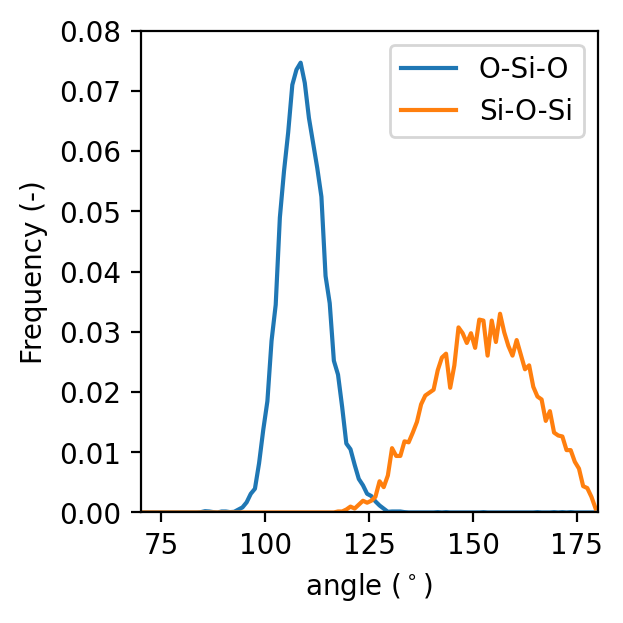

In [15]:
bond_angle_distribution_OSiO = compute_angles(
    atoms,
    center_type=[14],
    neighbor_type=[8],  # Assuming Si is the center for O-Si-O angles
    cutoff=2,
    bins=180,
)

bond_angle_distribution_SiOSi = compute_angles(
    atoms,
    center_type=[8],
    neighbor_type=[14],  # Assuming Si is the center for O-Si-O angles
    cutoff=2,
    bins=180,
)


fig, ax = plt.subplots(1, 1, figsize=(3, 3), dpi=200, layout="constrained")

# Unpack the result to ensure correct usage
angles, counts = bond_angle_distribution_OSiO
ax.plot(
    angles,
    counts,
    label="O-Si-O",
    color="C0",
)

angles, counts = bond_angle_distribution_SiOSi
ax.plot(
    angles,
    counts,
    label="Si-O-Si",
    color="C1",
)

ax.set_xlim(70, 180)
ax.set_ylim(0, 0.08)
ax.set_xlabel(r"angle $(^\circ)$")
ax.set_ylabel(r"Frequency (-)")
ax.legend()

plt.show()

# Radial distribution function:

The cell below serves as a show case for calculating:

- radial distribution function

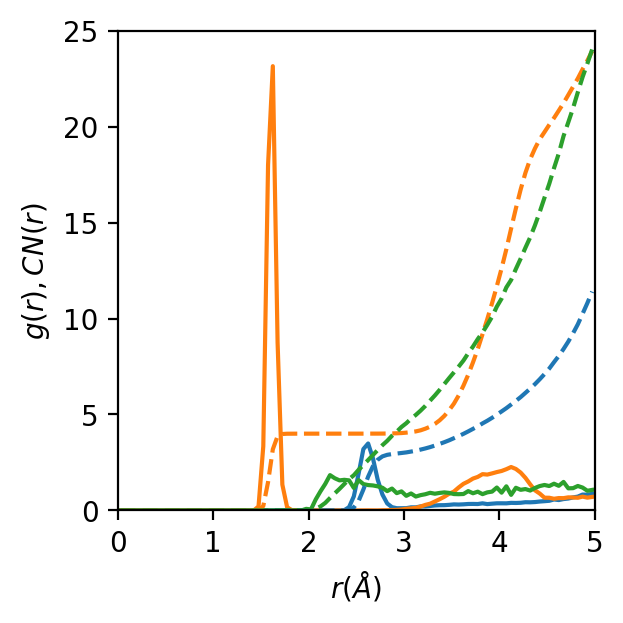

In [5]:
r, rdfs, cumcn = compute_rdf(atoms, r_max=5, n_bins=100)


fig, ax = plt.subplots(1, 1, figsize=(3, 3), dpi=200, layout="constrained")

ax.plot(r, rdfs[(8, 8)], "-", color="C0", label=r"$g_{1-1}(r)$")
ax.plot(r, rdfs[(14, 8)], "-", color="C1", label=r"$g_{2-1}(r)$")
ax.plot(r, rdfs[(11, 8)], "-", color="C2", label=r"$g_{3-1}(r)$")
ax.plot(r, cumcn[(8, 8)], "--", color="C0", label=r"$CN_{1-1}(r)$")
ax.plot(r, cumcn[(14, 8)], "--", color="C1", label=r"$CN_{2-1}(r)$")
ax.plot(r, cumcn[(11, 8)], "--", color="C2", label=r"$CN_{3-1}(r)$")
ax.set_xlim(0, 5)
ax.set_ylim(0, 25)
ax.set_xlabel(r"$r (\AA)$")
ax.set_ylabel(r"$g(r), CN(r)$")
# ax.legend()

plt.show()

# Rings Calculation:

The cell below serves as a show case for calculating:

- Guttman rings statistics

100%|██████████| 12696/12696 [00:04<00:00, 2795.58it/s]


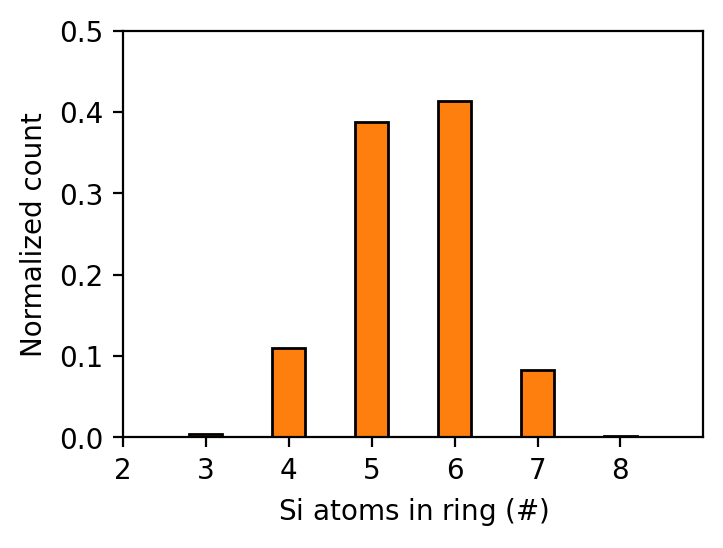

In [6]:
specific_cutoffs = {
    ("Si", "O"): 2.0,
}

bond_lengths = generate_bond_length_dict(atoms, specific_cutoffs=specific_cutoffs)

rings_dist, mean_ring_size = compute_guttmann_rings(
    atoms, bond_lengths=bond_lengths, max_size=40, n_cpus=1
)


sizes = np.array(sorted(rings_dist.keys()))
counts = np.array([rings_dist[s] for s in sizes])


fig, ax = plt.subplots(
    1, 1, figsize=(3.5, 3.5 / 1.333333), dpi=200, layout="constrained"
)

ax.bar(
    sizes / 2,
    counts / counts.sum(),
    width=0.4,
    align="center",
    linewidth=1,
    edgecolor="black",
    facecolor="C1",
)
ax.set_xlim(2, (sizes / 2).max() + 1)
ax.set_xticks(np.arange(2, (sizes / 2).max() + 1, 1))
ax.set_ylim(0, 0.5)
ax.set_xlabel(r"Si atoms in ring ($\#$)")
ax.set_ylabel(r"Normalized count")

plt.show()